In [162]:
import numpy as np
import pandas as pd

In [163]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivkp/customer-behaviour")

print("Path to dataset files:", path)

Path to dataset files: /home/jovyan/.cache/kagglehub/datasets/shivkp/customer-behaviour/versions/1


In [164]:
import os
import pandas as pd

# List all files in the dataset directory
files = os.listdir(path)
print("Files in dataset directory:", files)

# Create dataframes from CSV files
dataframes = {}
for file in files:
    if file.endswith('.csv'):
        file_path = os.path.join(path, file)
        df_name = os.path.splitext(file)[0]
        dataframes[df_name] = pd.read_csv(file_path, encoding='ISO-8859-1')


Files in dataset directory: ['tokenized_access_logs.csv', 'DescriptionDataCoSupplyChain.csv', 'DataCoSupplyChainDataset.csv']


In [165]:
data = dataframes['DataCoSupplyChainDataset']

Dropping product description columns because entire row was null

Dropping product status since all values were 0 indicating all products were available

In [166]:
data = data.drop(columns=['Product Description'])
data = data.drop(columns=['Product Status'])

In [167]:
# Remove duplicates 
data = data.drop_duplicates()
# Standardize column names (e.g., remove spaces, convert to lowercase) 
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[^a-z0-9_]', '')

In [168]:
# Create a table with column names, count of null values, and count of zeroes
null_counts = data.isnull().sum()
zero_counts = (data == 0).sum()

table = pd.DataFrame({
    'Column Name': data.columns,
    'Null Count': null_counts,
    'Zero Count': zero_counts
})

- We didn't drop null values in scheduled delivery vs real delivery time since 0 denotes same day delivery

- also didn't drop the zero values in order_profit_per order since discounts were given resulting in no profit

In [169]:
data['customer_country']

0         Puerto Rico
1         Puerto Rico
2             EE. UU.
3             EE. UU.
4         Puerto Rico
             ...     
180514        EE. UU.
180515        EE. UU.
180516        EE. UU.
180517    Puerto Rico
180518    Puerto Rico
Name: customer_country, Length: 180519, dtype: object

## Market Performance Overview

### Market Share


In [171]:
import matplotlib.pyplot as plt

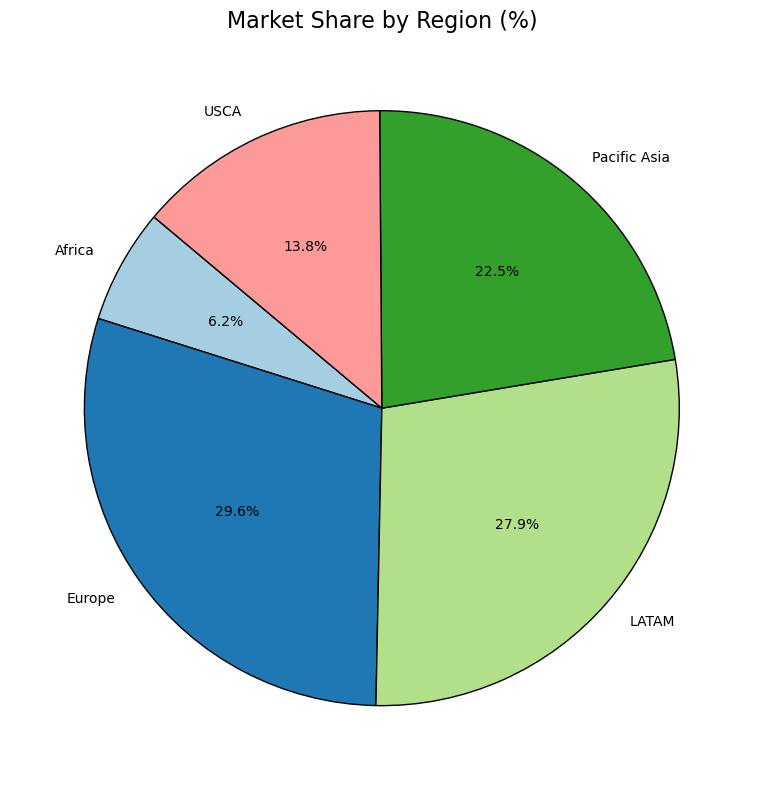

In [172]:
# Step 1: Group by Market and Sum Sales
grouped_data = data.groupby('market', as_index=False).agg(total_sales=('sales', 'sum'))

# Step 2: Calculate Market Share Percentage
total_sales = grouped_data['total_sales'].sum()
grouped_data['market_share_percentage'] = (grouped_data['total_sales'] / total_sales) * 100

# Step 3: Plot Pie Chart
plt.figure(figsize=(12, 8))
plt.pie(
    grouped_data['market_share_percentage'], 
    labels=grouped_data['market'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Paired.colors,
    wedgeprops={'edgecolor': 'black'}
)
plt.title('Market Share by Region (%)', fontsize=16)
plt.tight_layout()
plt.show()


### Category Contribution to Sales

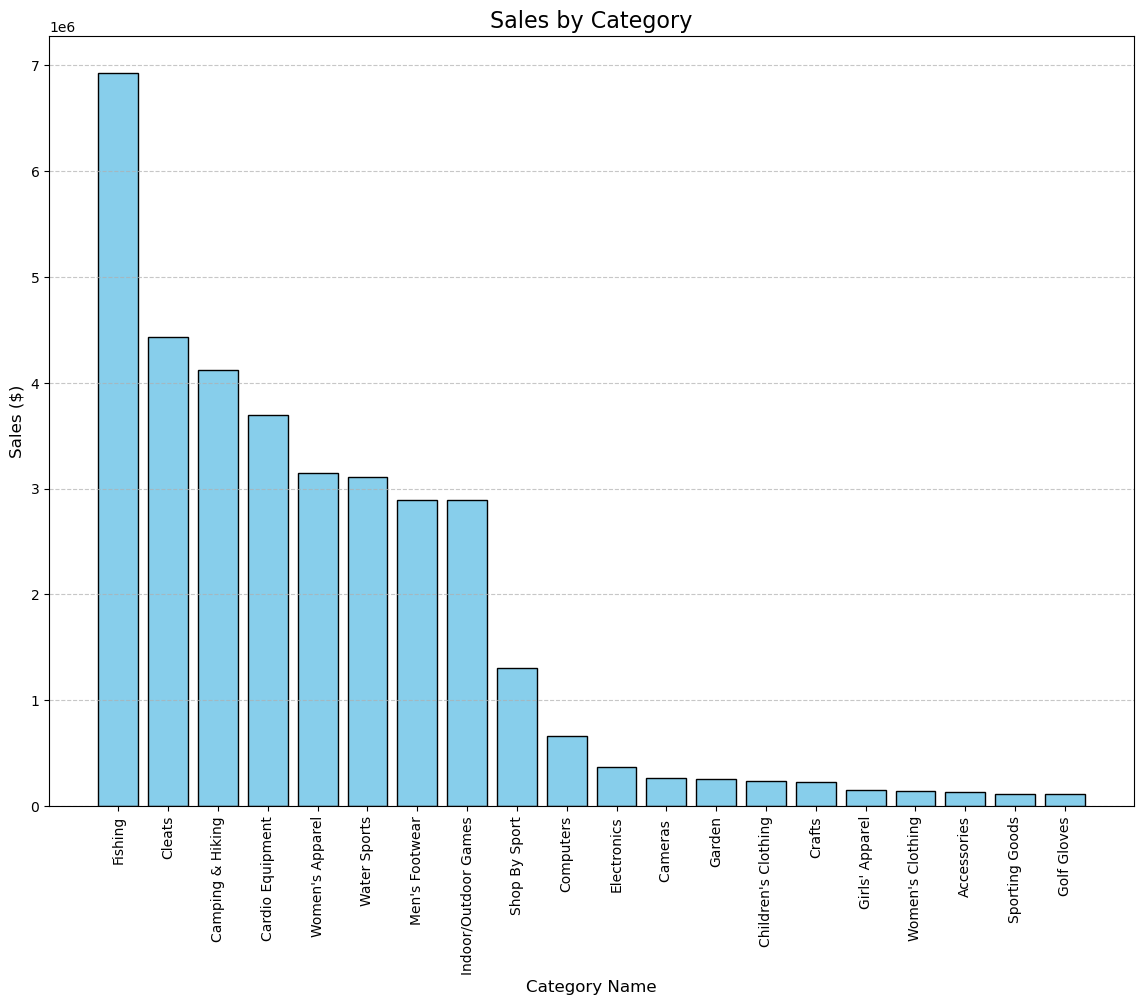

In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify

df = pd.DataFrame(data)

# Step 1: Group by category and sum the sales
category_sales = df.groupby('category_name')['sales'].sum().reset_index()

# Step 2: Sort categories by sales and select the top 20
top_20 = category_sales.nlargest(20, 'sales')

# Bar Chart: Sales by Category
plt.figure(figsize=(14, 10))
plt.bar(top_20['category_name'], top_20['sales'], color='skyblue', edgecolor='black')
plt.title('Sales by Category', fontsize=16)
plt.xlabel('Category Name', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


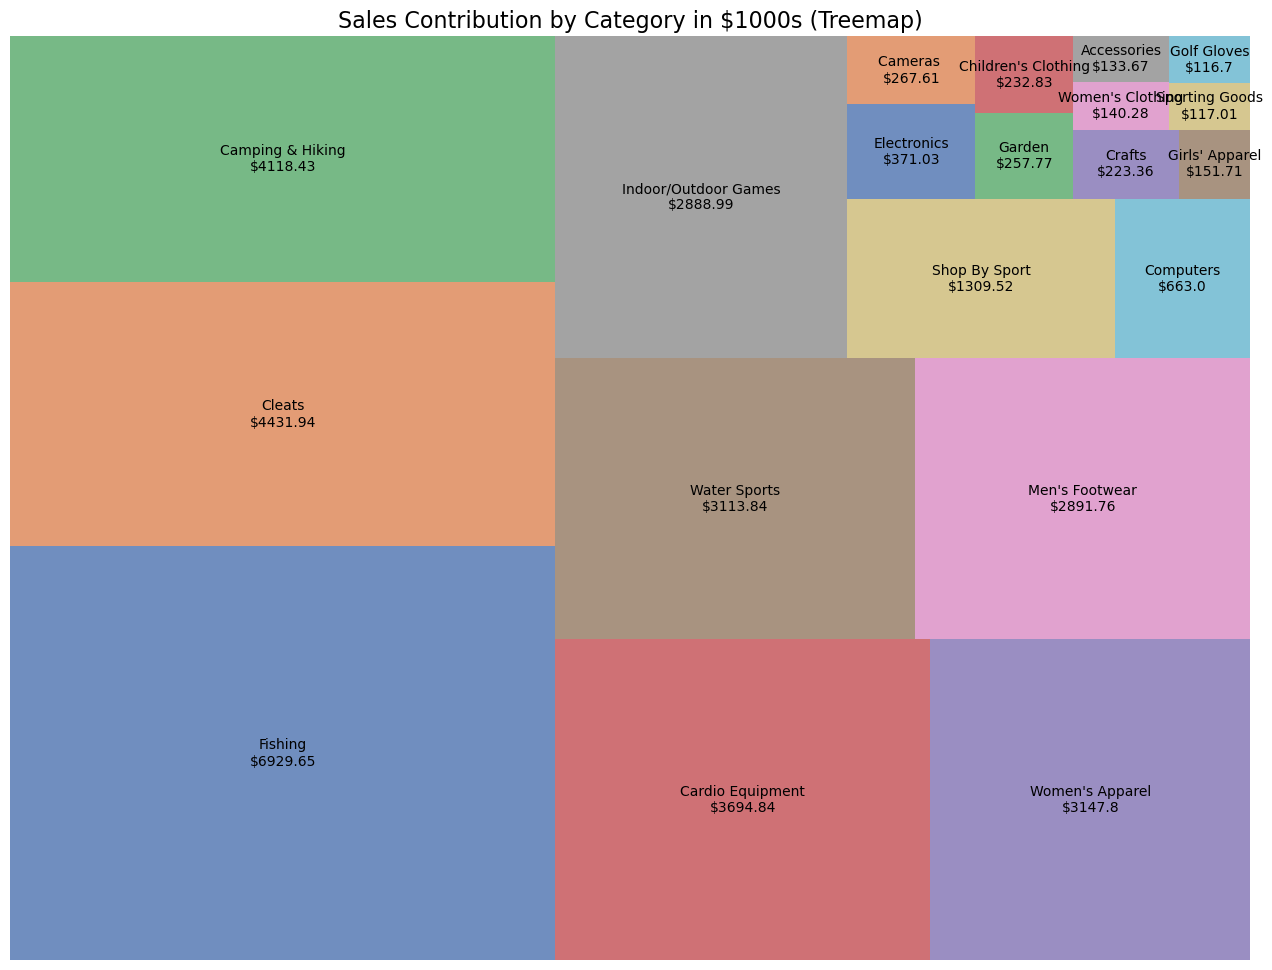

In [174]:
import seaborn as sns
colors = sns.color_palette("deep", len(category_sales))
# Step 2: Treemap Visualization
plt.figure(figsize=(16, 12))
top_20['sales'] = top_20['sales']/1000
top_20['sales'] = top_20['sales'].round(2)
squarify.plot(
    sizes=top_20['sales'], 
    label=[f"{cat}\n${sale}" for cat, sale in zip(top_20['category_name'], top_20['sales'])],
    color=colors,
    alpha=0.8,
)
plt.title('Sales Contribution by Category in $1000s (Treemap)', fontsize=16)
plt.axis('off')
plt.show()

### Top Perfroming Products

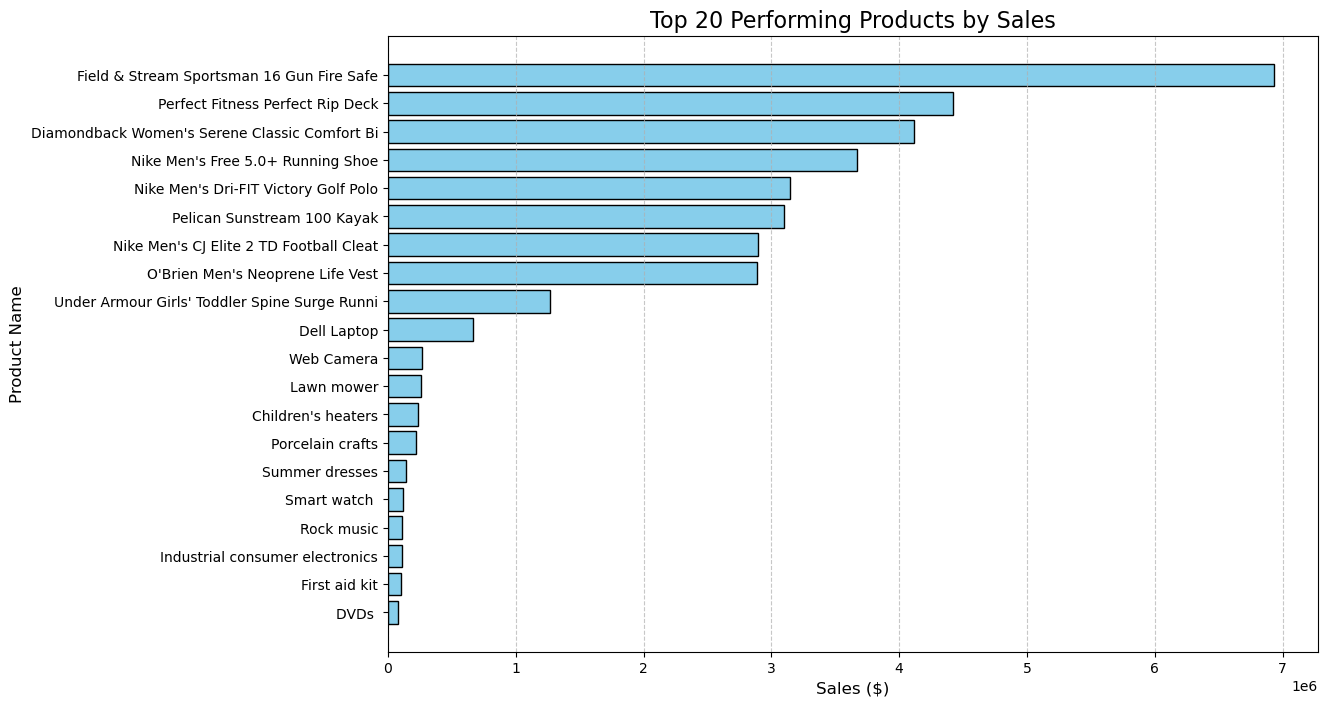

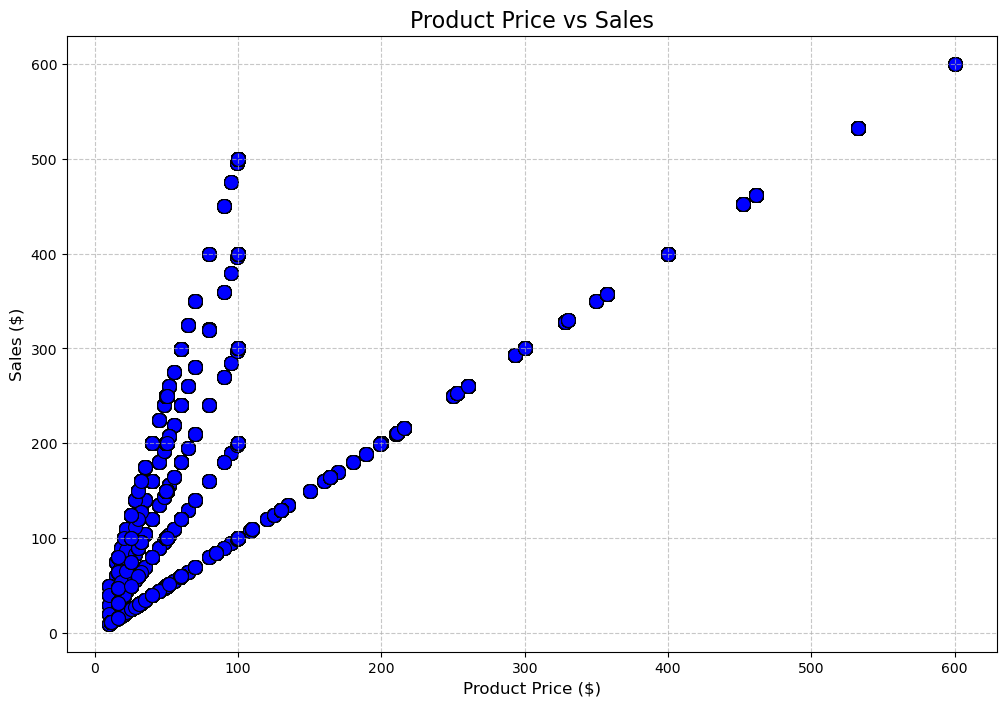

In [175]:
product_sales = df.groupby('product_name')['sales'].sum().reset_index()

top_20_prod = product_sales.nlargest(20,'sales')

# Step 2: Horizontal Bar Chart: Top 10 Products by Sales
plt.figure(figsize=(12, 8))
plt.barh(top_20_prod['product_name'], top_20_prod['sales'], color='skyblue', edgecolor='black')
plt.title('Top 20 Performing Products by Sales', fontsize=16)
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.gca().invert_yaxis()  # Invert y-axis to show the highest value at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

data = data[data['sales']<900]
# Step 3: Scatter Plot: Product Price vs Sales
plt.figure(figsize=(12, 8))
sns.scatterplot(data=data, x='product_price', y='sales', color='blue', s=100, edgecolor='black')
plt.title('Product Price vs Sales', fontsize=16)
plt.xlabel('Product Price ($)', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## Inventory Health

In [176]:
data['order_item_total']

0         314.640015
1         311.359985
2         309.720001
3         304.809998
4         298.250000
             ...    
180514    399.980011
180515    395.980011
180516    391.980011
180517    387.980011
180518    383.980011
Name: order_item_total, Length: 180052, dtype: float64

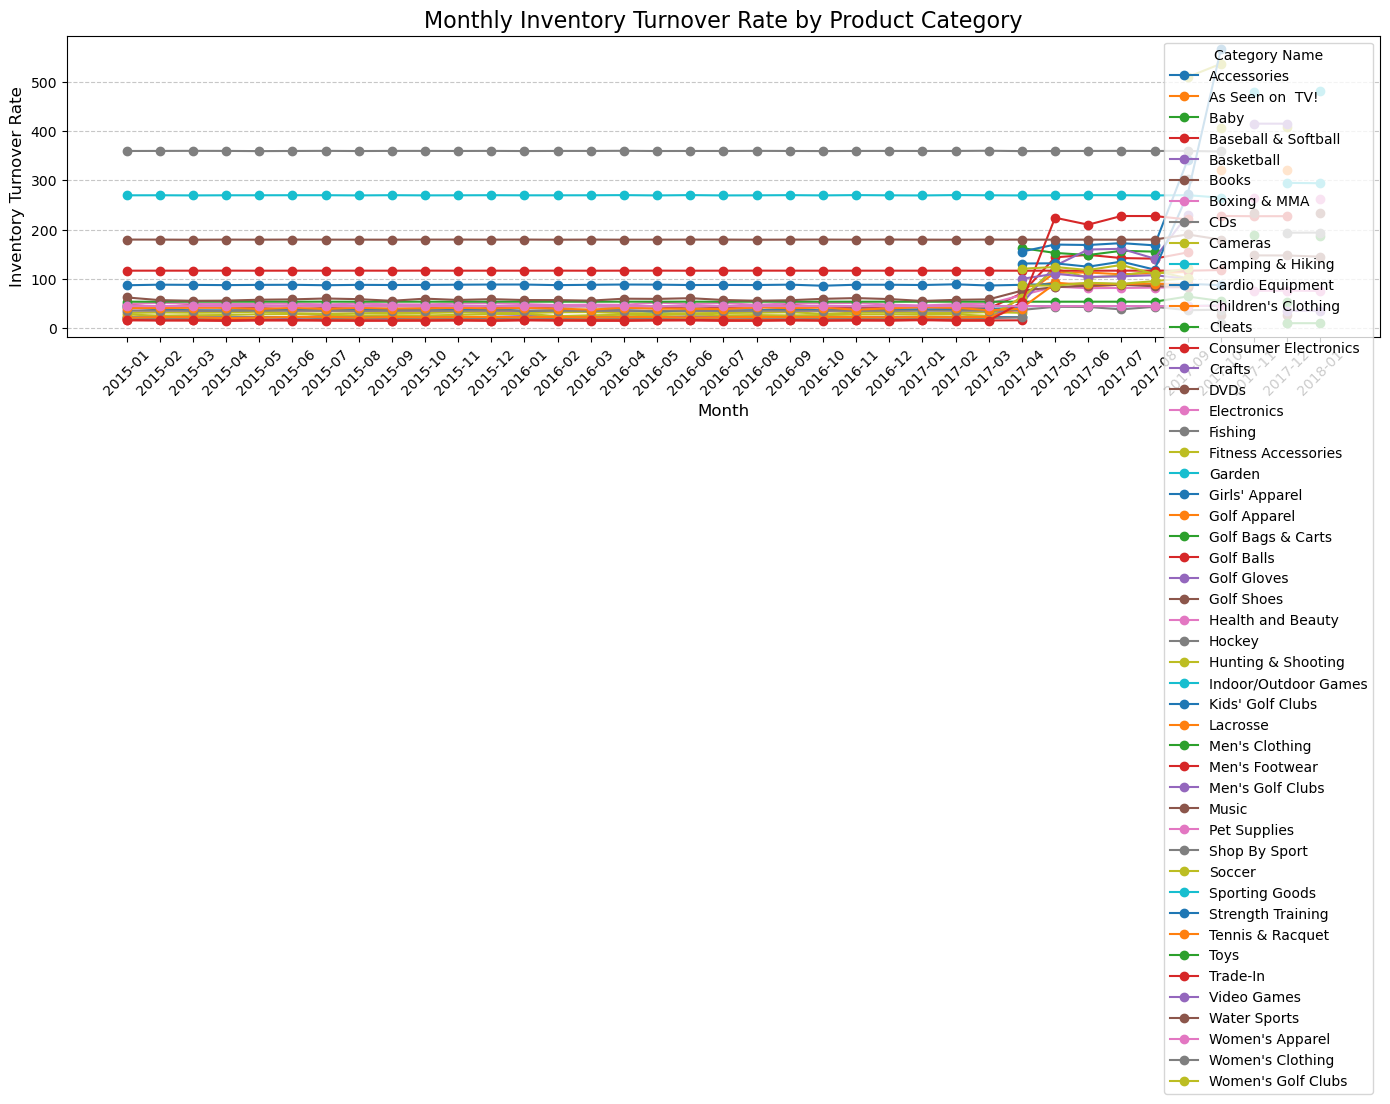

In [177]:
# Step 1: Preprocess data
data['order_date_(dateorders)'] = pd.to_datetime(data['order_date_(dateorders)'])  # Convert to datetime
data['Month'] = data['order_date_(dateorders)'].dt.to_period('M')  # Extract Year-Month

# Step 2: Calculate Inventory Turnover Rate
data['Inventory_Turnover_Rate'] = data['order_item_total'] / data['order_item_quantity']

# Step 3: Group by Month and Category Name
grouped_data = data.groupby(['Month', 'category_name'])['Inventory_Turnover_Rate'].mean().reset_index()

# Step 4: Pivot data for plotting
pivot_data = grouped_data.pivot(index='Month', columns='category_name', values='Inventory_Turnover_Rate')

# Step 5: Plot Line Chart
plt.figure(figsize=(14, 8))
for category in pivot_data.columns:
    plt.plot(pivot_data.index.astype(str), pivot_data[category], marker='o', label=category)

plt.title('Monthly Inventory Turnover Rate by Product Category', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Inventory Turnover Rate', fontsize=12)
plt.legend(title='Category Name', fontsize=10)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


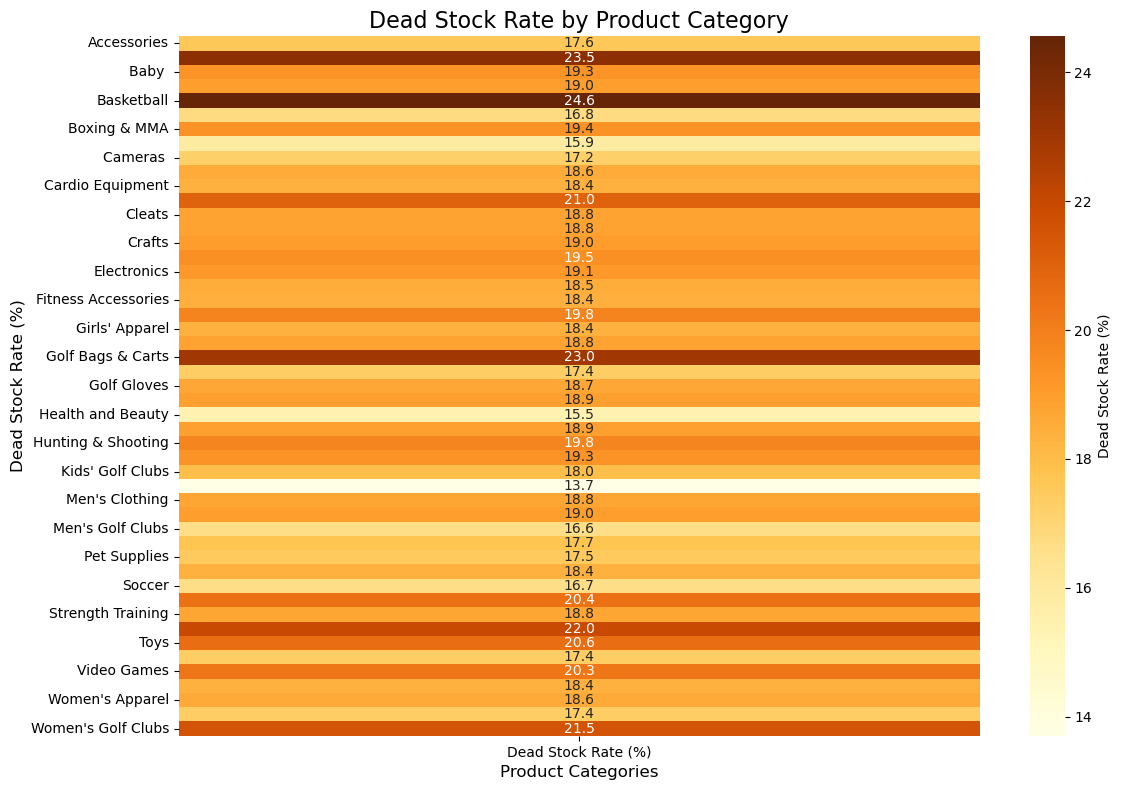

In [178]:
# Step 1: Approximate Unsold Products based on Order Status
# Assuming "CANCELED", "ON_HOLD", "PENDING" as indicators of unsold products
unsold_conditions = ['CANCELED', 'ON_HOLD', 'PENDING']
data['Unsold Products'] = data.apply(
    lambda row: row['order_item_quantity'] if row['order_status'] in unsold_conditions else 0, axis=1
)

# Step 2: Calculate Dead Stock Rate
data['Dead Stock Rate (%)'] = (data['Unsold Products'] / data['order_item_quantity']) * 100

# Step 3: Create Pivot Table for Heatmap
heatmap_data = data.pivot_table(index='category_name', values='Dead Stock Rate (%)')

# Step 4: Plot Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrBr", cbar_kws={'label': 'Dead Stock Rate (%)'})
plt.title('Dead Stock Rate by Product Category', fontsize=16)
plt.xlabel('Product Categories', fontsize=12)
plt.ylabel('Dead Stock Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()


## Operational Efficiency

###  Order Fulfillment Time

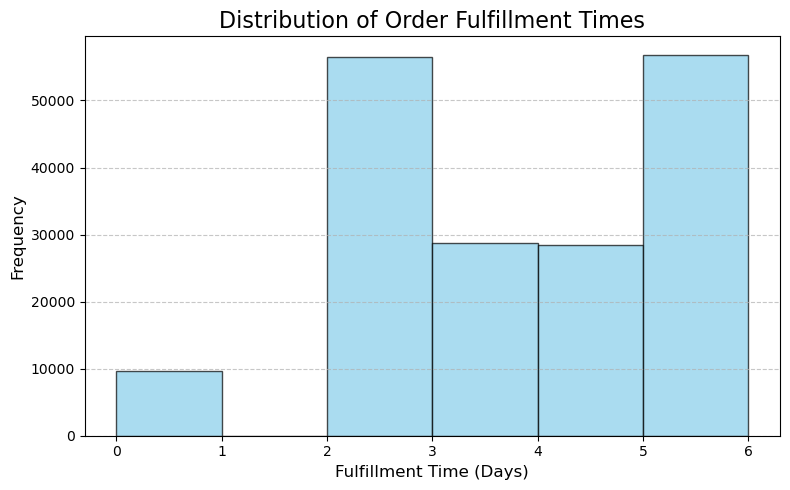

In [179]:
# Step 1: Convert dates to datetime format
data['Order Date'] = pd.to_datetime(data['order_date_(dateorders)'])
data['Shipping Date'] = pd.to_datetime(data['shipping_date_(dateorders)'])

# Step 2: Calculate Order Fulfillment Time
data['Fulfillment Time (Days)'] = (data['Shipping Date'] - data['Order Date']).dt.days

# Step 3: Plot Histogram
plt.figure(figsize=(8, 5))
plt.hist(data['Fulfillment Time (Days)'], bins=6, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Order Fulfillment Times', fontsize=16)
plt.xlabel('Fulfillment Time (Days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


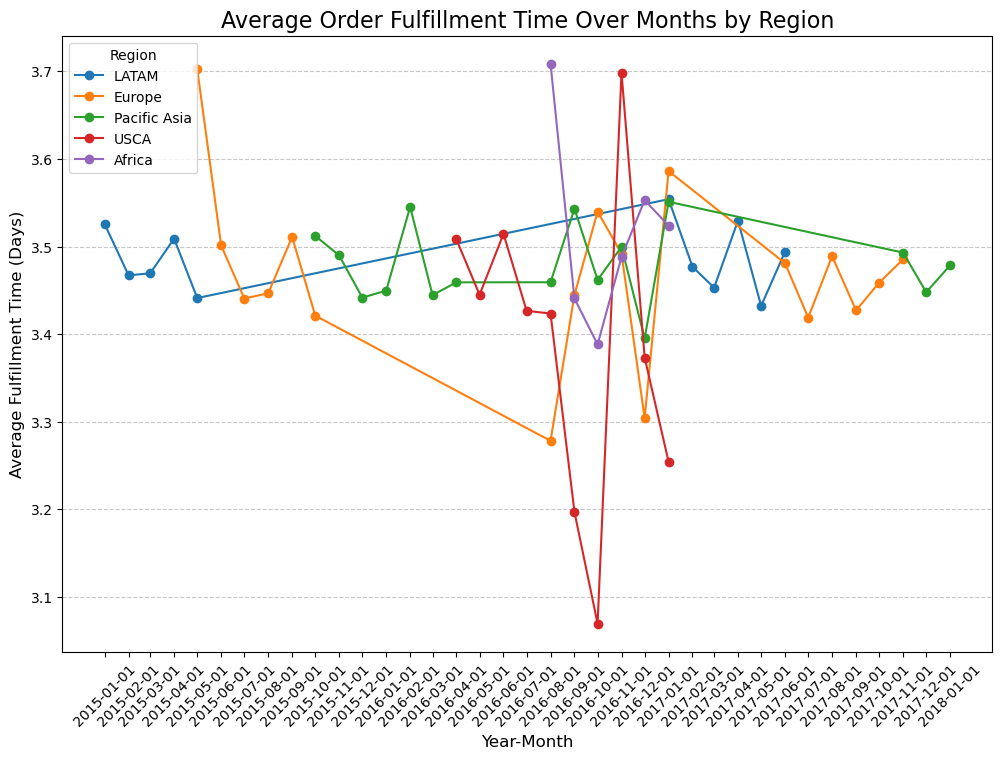

In [180]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Convert dates to datetime
data['order_date'] = pd.to_datetime(data['order_date_(dateorders)'])
data['shipping_date'] = pd.to_datetime(data['shipping_date_(dateorders)'])

# Step 2: Calculate Order Fulfillment Time
data['fulfillment_time'] = (data['shipping_date'] - data['order_date']).dt.days

# Step 3: Group by Year, Month, and Region, Calculate Average Fulfillment Time
data['year'] = data['order_date'].dt.year
data['month'] = data['order_date'].dt.month

# Group by year, month, and market
monthly_data = data.groupby(['year', 'month', 'market']).agg(
    avg_fulfillment_time=('fulfillment_time', 'mean')
).reset_index()

# Sort the data by year and month
monthly_data = monthly_data.sort_values(by=['year', 'month'])
monthly_region_data = monthly_data.sort_values(by='market')

# Step 4: Plot Line Chart with Different Colors for Regions
plt.figure(figsize=(12, 8))

# Plot each region separately with unique colors
# Convert 'year' and 'month' to datetime format for proper sorting
monthly_data['date'] = pd.to_datetime(monthly_data[['year', 'month']].assign(day=1))

# Sort the data by date
monthly_data = monthly_data.sort_values(by='date')

regions = monthly_data['market'].unique()
for region in regions:
    region_data = monthly_data[monthly_data['market'] == region]
    plt.plot(
        region_data['date'],
        region_data['avg_fulfillment_time'],
        marker='o',
        label=region
    )

plt.title('Average Order Fulfillment Time Over Months by Region', fontsize=16)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Average Fulfillment Time (Days)', fontsize=12)
plt.xticks(monthly_data['date'].unique(), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Region', loc='upper left')


### Order Processing Accuracy

In [181]:
data['order_status'].value_counts()

order_status
COMPLETE           59324
PENDING_PAYMENT    39741
PROCESSING         21832
PENDING            20187
CLOSED             19562
ON_HOLD             9781
SUSPECTED_FRAUD     4051
CANCELED            3686
PAYMENT_REVIEW      1888
Name: count, dtype: int64

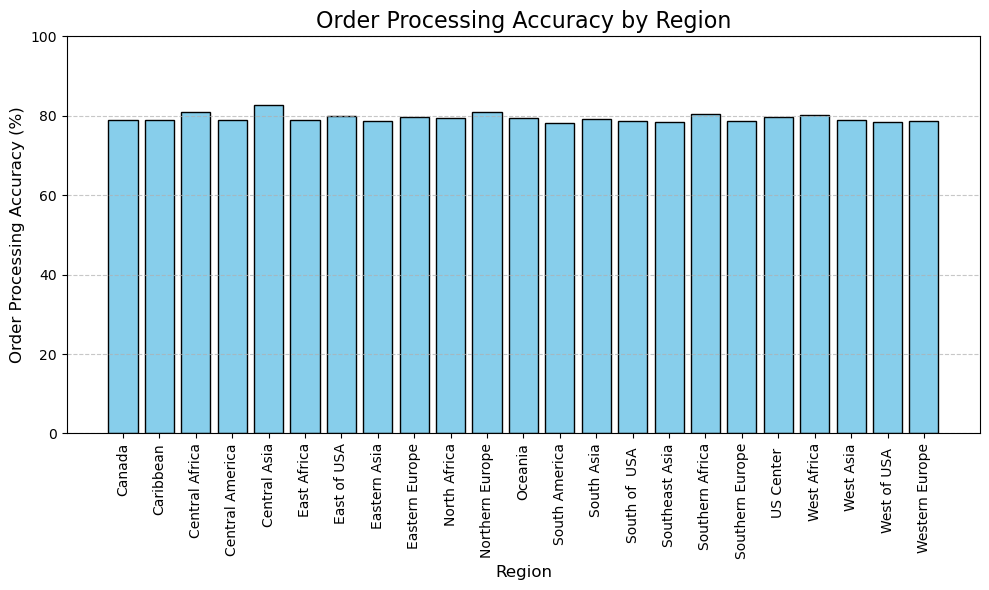

In [182]:
# Step 1: Determine Correctly Processed Orders
# Assuming "COMPLETE" indicates correctly processed orders
data['Correct Order'] = data['order_status'].apply(lambda x: 1 if x in ['COMPLETE', 'PENDING_PAYMENT', 'PROCESSING', 'PAYMENT_REVIEW','CLOSED'] else 0)

# Step 2: Group by Region and Calculate Accuracy
grouped_data = data.groupby('order_region').agg(
    Total_Orders=('order_id', 'count'),
    Correct_Orders=('Correct Order', 'sum')
).reset_index()
grouped_data['Order Processing Accuracy (%)'] = (grouped_data['Correct_Orders'] / grouped_data['Total_Orders']) * 100

# Step 3: Plot Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(grouped_data['order_region'], grouped_data['Order Processing Accuracy (%)'], color='skyblue', edgecolor='black')
plt.title('Order Processing Accuracy by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Order Processing Accuracy (%)', fontsize=12)
plt.ylim(0, 100)  # Ensure the y-axis ranges from 0 to 100%
plt.xticks(rotation=90) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Shipping and Delivery

### Late Delivery Risk Rate

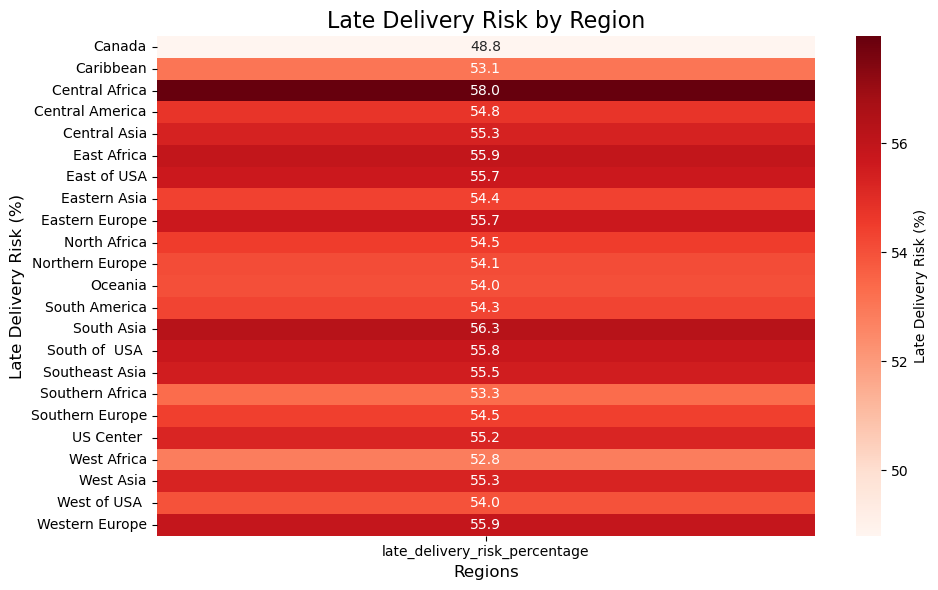

In [183]:

# Step 1: Group by Region and Calculate Late Delivery Risk Rate
grouped_data = data.groupby('order_region').agg(
    total_orders=('order_id', 'count'),
    late_orders=('late_delivery_risk', 'sum')
).reset_index()
grouped_data['late_delivery_risk_percentage'] = (grouped_data['late_orders'] / grouped_data['total_orders']) * 100

# Step 2: Prepare Data for Heatmap
heatmap_data = grouped_data.pivot_table(index='order_region', values='late_delivery_risk_percentage')

# Step 3: Plot Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'Late Delivery Risk (%)'})
plt.title('Late Delivery Risk by Region', fontsize=16)
plt.xlabel('Regions', fontsize=12)
plt.ylabel('Late Delivery Risk (%)', fontsize=12)
plt.tight_layout()
plt.show()


### On-Time Delivery Rate

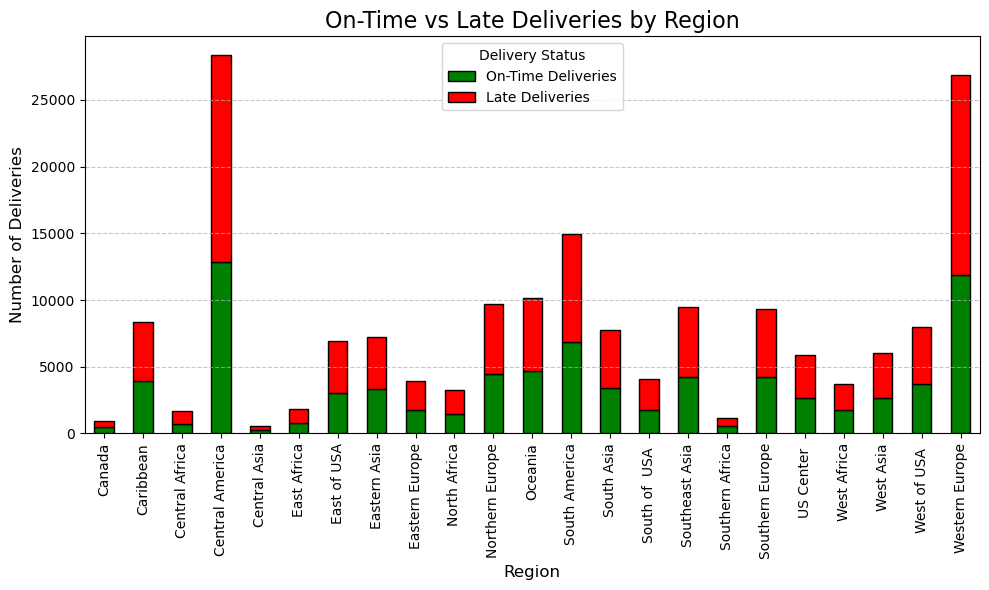

In [184]:
# Step 1: Group by Region and Calculate On-Time and Late Deliveries
grouped_data = data.groupby('order_region').agg(
    total_orders=('order_id', 'count'),
    on_time_deliveries=('late_delivery_risk', lambda x: (x == 0).sum()),
    late_deliveries=('late_delivery_risk', 'sum')
).reset_index()

# Step 2: Calculate On-Time Delivery Rate
grouped_data['on_time_delivery_rate_percentage'] = (grouped_data['on_time_deliveries'] / grouped_data['total_orders']) * 100

# Step 3: Prepare Data for Stacked Bar Chart
grouped_data.set_index('order_region', inplace=True)
stacked_data = grouped_data[['on_time_deliveries', 'late_deliveries']]

# Step 4: Plot Stacked Bar Chart
stacked_data.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['green', 'red'],
    edgecolor='black'
)

plt.title('On-Time vs Late Deliveries by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Deliveries', fontsize=12)
plt.legend(['On-Time Deliveries', 'Late Deliveries'], title='Delivery Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Profitability Analysis 

### Profit Margin Per Order

/tmp/ipykernel_62436/304028794.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category_name', y='profit_margin_percentage', data=data, palette='deep')


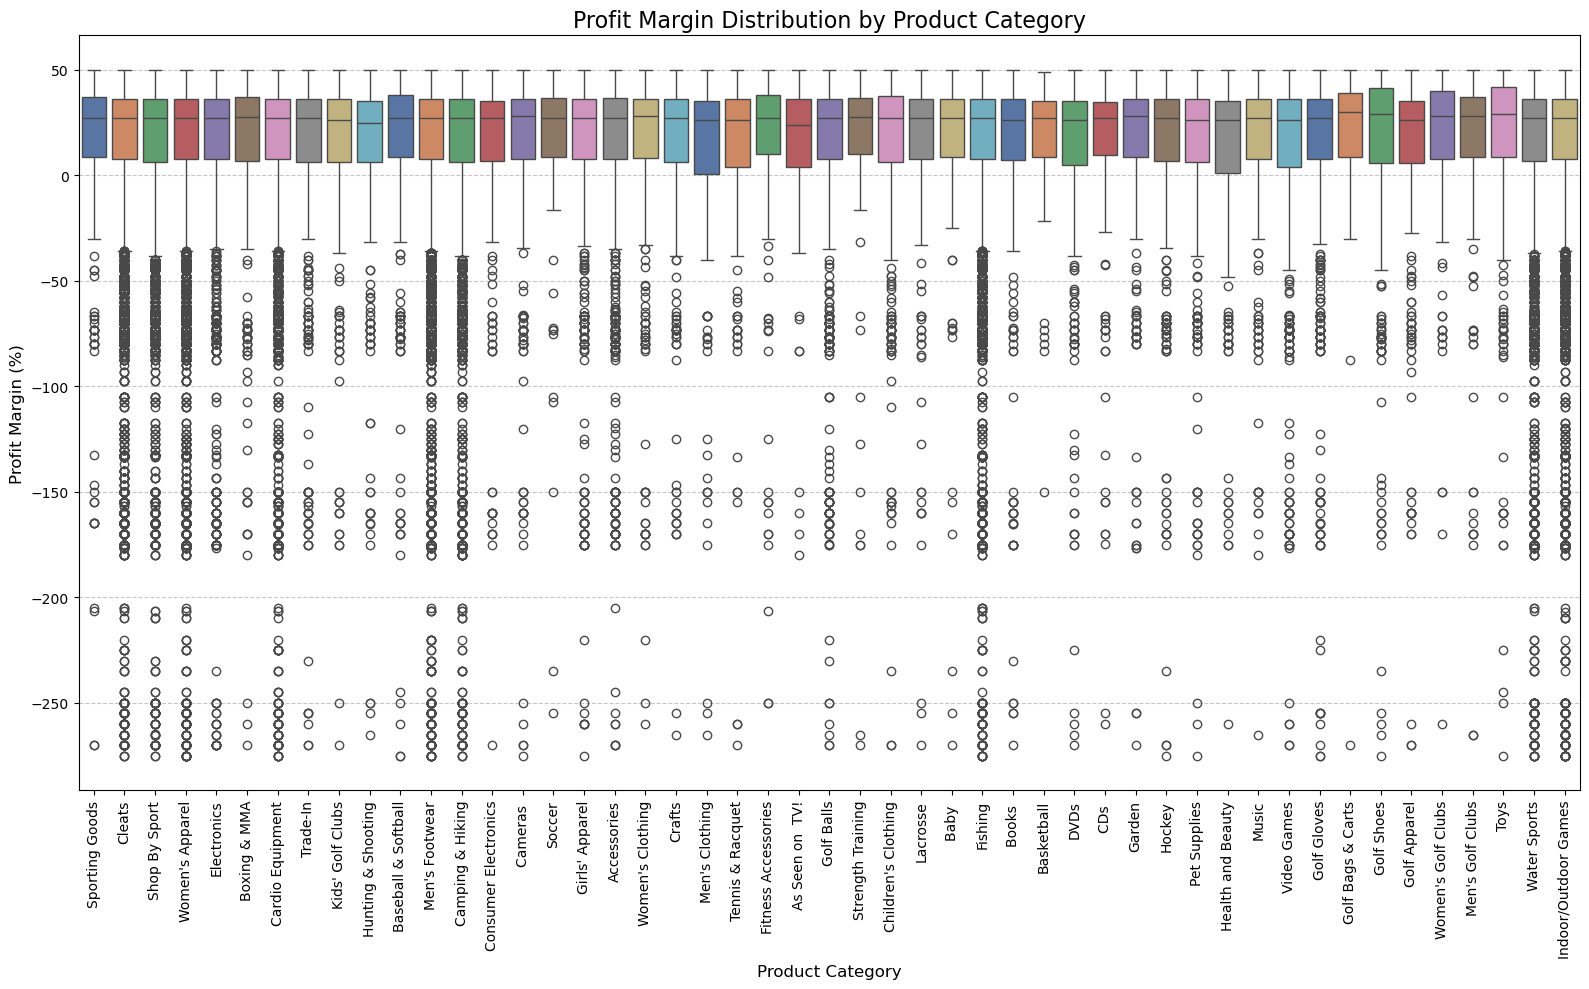

In [185]:

# Step 1: Calculate Adjusted Profit and Profit Margin
data['profit_margin_percentage'] = (data['benefit_per_order'] / data['order_item_total']) * 100

# Step 2: Box Plot for Profit Margin Distribution by Product Category
plt.figure(figsize=(16, 10))
sns.boxplot(x='category_name', y='profit_margin_percentage', data=data, palette='deep')
plt.title('Profit Margin Distribution by Product Category', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Profit Margin (%)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



## Customer Satisfaction